Final predicted a: 3.9820
Final predicted b: 6.2138
Range of 'a' after 100 iterations: (0.0000, 3.9968)
Range of 'b' after 100 iterations: (0.0000, 6.2138)


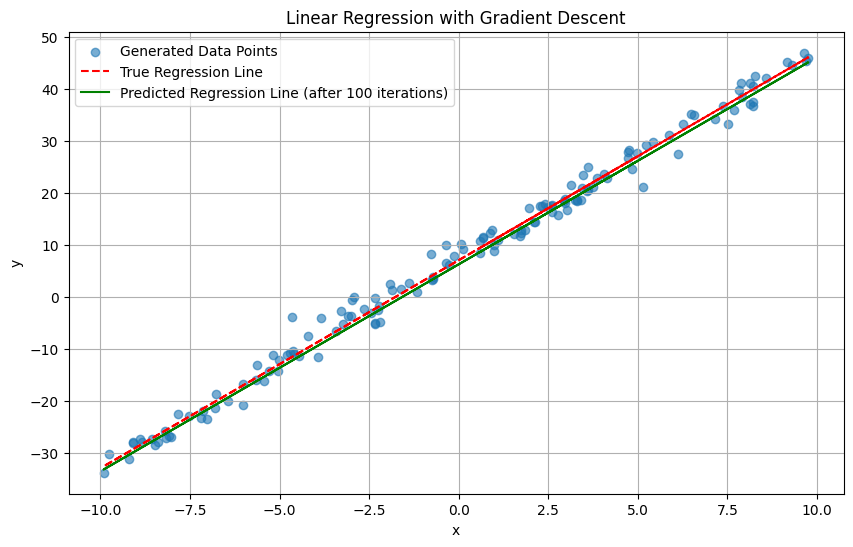

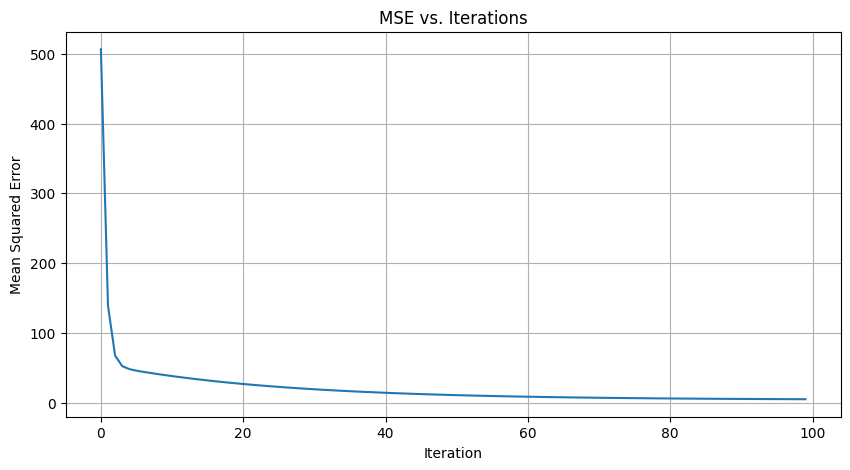

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate random points
np.random.seed(42)  # for reproducibility
num_samples = 200
#x = np.random.normal(loc=0, scale=5, size=num_samples)
x = np.random.normal(0, 10, num_samples)
#x= linspace(-10,10,200)
# Filter x to be within -10 and 10
x = x[(x >= -10) & (x <= 10)]
num_samples = len(x) # Update num_samples after filtering

# True equation: y = 4x + 7
true_a = 4
true_b = 7
y_true = true_a * x + true_b

# Add some noise to y to simulate real-world data
noise = np.random.normal(loc=0, scale=2, size=num_samples) # Adjust noise level as needed
y = y_true + noise

# 2. Implement Gradient Descent
# Initial values for a and b (can be varied)
a = 0.0
b = 0.0

# Learning rate (eta) - can be varied
learning_rate = 0.01

# Number of iterations
num_iterations = 100

# Store values for plotting/analysis
a_history = [a]
b_history = [b]
mse_history = []

for k in range(num_iterations):
    # Predicted y
    y_pred = a * x + b

    # Mean Squared Error (MSE)
    mse = np.mean((y_pred - y)**2)
    mse_history.append(mse)

    # Gradients of MSE with respect to a and b
    grad_a = np.mean(2 * (y_pred - y) * x)
    grad_b = np.mean(2 * (y_pred - y))

    # Update a and b using gradient descent
    a = a - learning_rate * grad_a
    b = b - learning_rate * grad_b

    a_history.append(a)
    b_history.append(b)

# Final predicted values of a and b after 100 iterations
final_a = a_history[-1]
final_b = b_history[-1]

print(f"Final predicted a: {final_a:.4f}")
print(f"Final predicted b: {final_b:.4f}")

# Determine the range for predicted values of a and b after 100 iterations
# This depends on the specific run, but we can compare to the given options
print(f"Range of 'a' after 100 iterations: ({min(a_history):.4f}, {max(a_history):.4f})")
print(f"Range of 'b' after 100 iterations: ({min(b_history):.4f}, {max(b_history):.4f})")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Generated Data Points', alpha=0.6)
plt.plot(x, true_a * x + true_b, color='red', label='True Regression Line', linestyle='--')
plt.plot(x, final_a * x + final_b, color='green', label='Predicted Regression Line (after 100 iterations)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(num_iterations), mse_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs. Iterations')
plt.grid(True)
plt.show()